# 02 — Market Basket Analysis (Apriori)
Build a boolean invoice×item matrix from UK transactions and mine association rules.

In [ ]:
%matplotlib inline

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from mlxtend.frequent_patterns import apriori, association_rules

PROJECT_ROOT = Path.cwd().parent
PROCESSED = PROJECT_ROOT / "data" / "processed" / "online_retail_clean.csv"
FIGURES   = PROJECT_ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED)
print(f"Loaded {len(df):,} rows")

In [3]:
# Filter to UK transactions only (largest market)
uk = df[df["Country"] == "United Kingdom"].copy()
print(f"UK transactions: {len(uk):,}  ({len(uk)/len(df)*100:.1f}% of total)")
print(f"Unique UK invoices: {uk['InvoiceNo'].nunique():,}")

UK transactions: 485,123  (91.5% of total)
Unique UK invoices: 18,021


In [4]:
# Build invoice x item boolean matrix
# Group by InvoiceNo and Description, sum quantities, then binarize
basket = (
    uk.groupby(["InvoiceNo", "Description"])["Quantity"]
    .sum()
    .unstack(fill_value=0)
)

# 1 if item was purchased, 0 otherwise
basket_sets = basket.map(lambda x: True if x > 0 else False)

print(f"Matrix shape: {basket_sets.shape[0]:,} invoices × {basket_sets.shape[1]:,} items")

Matrix shape: 18,021 invoices × 3,996 items


In [5]:
# Run Apriori with initial support threshold of 0.02
MIN_SUPPORT = 0.02

frequent_itemsets = apriori(
    basket_sets,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    verbose=1
)

print(f"\nFrequent itemsets found: {len(frequent_itemsets):,}")
frequent_itemsets.sort_values("support", ascending=False).head(10)

Processing 28 combinations | Sampling itemset size 4 32

Frequent itemsets found: 401


,support,itemsets
281,0.119971,(WHITE HANGING HEART T-LIGHT HOLDER)
109,0.107375,(JUMBO BAG RED RETROSPOT)
204,0.093502,(REGENCY CAKESTAND 3 TIER)
165,0.088397,(PARTY BUNTING)
135,0.077243,(LUNCH BAG RED RETROSPOT)
17,0.076078,(ASSORTED COLOUR BIRD ORNAMENT)
225,0.068864,(SET OF 3 CAKE TINS PANTRY DESIGN)
147,0.067643,(NATURAL SLATE HEART CHALKBOARD)
128,0.067477,(LUNCH BAG BLACK SKULL.)
88,0.064591,(HEART OF WICKER SMALL)


In [6]:
pd.set_option("display.max_rows", None)

# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0
)

print(f"Total rules generated: {len(rules):,}")

# Filter: confidence >= 0.5 and lift >= 2
strong_rules = rules[(rules["confidence"] >= 0.5) & (rules["lift"] >= 2.0)]
strong_rules = strong_rules.sort_values("lift", ascending=False)
print(f"Strong rules (conf≥0.5, lift≥2): {len(strong_rules):,}")
strong_rules[["antecedents", "consequents", "support", "confidence", "lift"]]

Total rules generated: 218
Strong rules (conf≥0.5, lift≥2): 76


,antecedents,consequents,support,confidence,lift
192,(WOODEN HEART CHRISTMAS SCANDINAVIAN),(WOODEN STAR CHRISTMAS SCANDINAVIAN),0.020421,0.722986,27.200282
193,(WOODEN STAR CHRISTMAS SCANDINAVIAN),(WOODEN HEART CHRISTMAS SCANDINAVIAN),0.020421,0.768267,27.200282
198,(PINK REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...",0.027301,0.700855,18.043004
195,"(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.027301,0.702857,18.043004
199,(GREEN REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.027301,0.527897,17.455471
194,"(ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.027301,0.902752,17.455471
197,(ROSES REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.027301,0.514644,16.101399
196,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER),0.027301,0.854167,16.101399
32,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.031963,0.618026,15.865302
33,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.031963,0.820513,15.865302


In [7]:
# Hyperparameter tuning: vary support threshold
support_thresholds = [0.01, 0.015, 0.02, 0.025, 0.03, 0.04, 0.05]
tuning_results = []

for sup in support_thresholds:
    fi = apriori(basket_sets, min_support=sup, use_colnames=True, verbose=0)
    r  = association_rules(fi, metric="lift", min_threshold=1.0) if len(fi) > 0 else pd.DataFrame()
    tuning_results.append({
        "min_support": sup,
        "frequent_itemsets": len(fi),
        "rules_total": len(r),
        "rules_conf50": len(r[r["confidence"] >= 0.5]) if len(r) > 0 else 0,
    })

tuning_df = pd.DataFrame(tuning_results)
print(tuning_df.to_string(index=False))

 min_support  frequent_itemsets  rules_total  rules_conf50
       0.010               2155         4368          1203
       0.015                755          736           225
       0.020                401          218            76
       0.025                231           86            39
       0.030                145           22            15
       0.040                 66            2             1
       0.050                 34            0             0


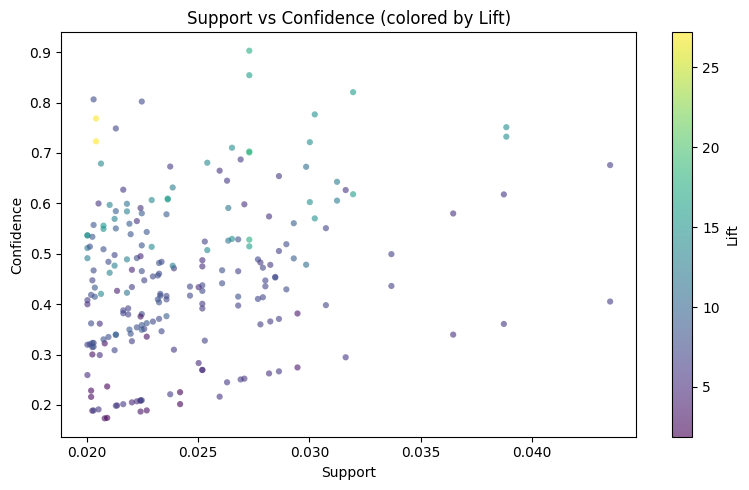

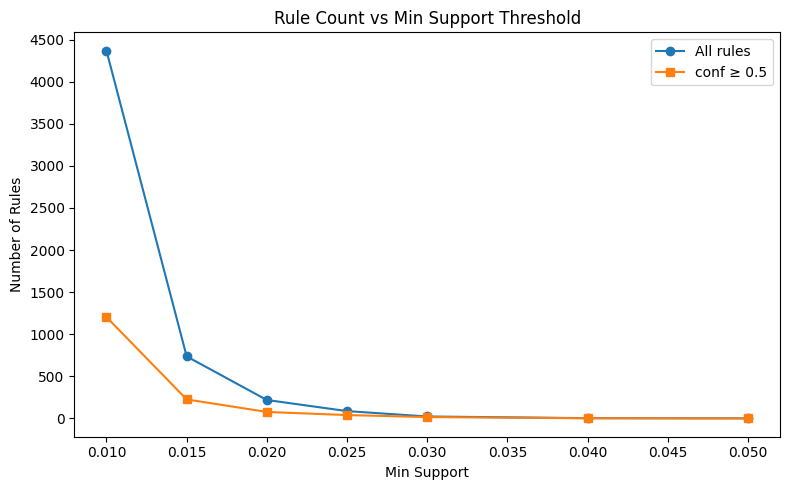

In [8]:
# Scatter plot: support vs confidence, colored by lift
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    rules["support"],
    rules["confidence"],
    c=rules["lift"],
    cmap="viridis",
    alpha=0.6,
    edgecolors="none",
    s=20,
)
plt.colorbar(sc, ax=ax, label="Lift")
ax.set_xlabel("Support")
ax.set_ylabel("Confidence")
ax.set_title("Support vs Confidence (colored by Lift)")
plt.tight_layout()
fig.savefig(FIGURES / "market_basket_scatter.png", dpi=150)
plt.show()

# Line plot: rule count vs min support threshold
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tuning_df["min_support"], tuning_df["rules_total"],  marker="o", label="All rules")
ax.plot(tuning_df["min_support"], tuning_df["rules_conf50"], marker="s", label="conf ≥ 0.5")
ax.set_xlabel("Min Support")
ax.set_ylabel("Number of Rules")
ax.set_title("Rule Count vs Min Support Threshold")
ax.legend()
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
fig.savefig(FIGURES / "market_basket_tuning.png", dpi=150)
plt.show()

## Interpretation and Mined Insights

The strongest mined rules are products which are the same type, but in color or style variants. For example, many of the strongest rules are all a set of teacups in a particular color, purchased together with another set of teacups in a different color. The most basic business insight from this analysis is that providing color or style variants of a product is a good way to sell multiple items.